In [15]:
!zip -r test_set.zip /content/test_set/

  adding: content/test_set/ (stored 0%)
  adding: content/test_set/ISIC_0028742.jpg (deflated 0%)
  adding: content/test_set/ISIC_0030069.jpg (deflated 0%)
  adding: content/test_set/ISIC_0028835.jpg (deflated 0%)
  adding: content/test_set/ISIC_0027983.jpg (deflated 0%)
  adding: content/test_set/ISIC_0033625.jpg (deflated 0%)
  adding: content/test_set/ISIC_0033440.jpg (deflated 0%)
  adding: content/test_set/ISIC_0026226.jpg (deflated 0%)
  adding: content/test_set/ISIC_0028476.jpg (deflated 0%)
  adding: content/test_set/ISIC_0031832.jpg (deflated 0%)
  adding: content/test_set/ISIC_0028757.jpg (deflated 0%)
  adding: content/test_set/ISIC_0028825.jpg (deflated 0%)
  adding: content/test_set/ISIC_0029256.jpg (deflated 0%)
  adding: content/test_set/ISIC_0029157.jpg (deflated 0%)
  adding: content/test_set/ISIC_0029275.jpg (deflated 0%)
  adding: content/test_set/ISIC_0025537.jpg (deflated 0%)
  adding: content/test_set/ISIC_0028157.jpg (deflated 0%)
  adding: content/test_set/ISIC_

In [ ]:
import keras
keras.__version__

'3.13.2'

In [1]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:32<00:00, 174MB/s]



In [2]:
!unzip skin-cancer-mnist-ham10000.zip

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  inflating: ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: ham10000_images_part_2/ISIC_0029340.jpg  
  inflating: ham10000_images_part_2/ISIC_0

In [3]:
import os
import random
import shutil
from pathlib import Path

def move_random_files(source_folders, target_folder, files_per_folder=333):
    """
    Moves a specified number of random files from multiple source folders into a target folder.

    :param source_folders: List or tuple of paths to the 3 source directories.
    :param target_folder: Path to the destination directory.
    :param files_per_folder: Number of random files to pick from each source folder.
    """
    target_path = Path(target_folder)
    target_path.mkdir(parents=True, exist_ok=True)

    total_moved = 0

    for folder in source_folders:
        src_path = Path(folder)
        if not src_path.exists() or not src_path.is_dir():
            print(f"[-] Warning: Source folder '{folder}' does not exist or is not a directory. Skipping.")
            continue

        # Collect all files (excluding subdirectories)
        files = [f for f in src_path.iterdir() if f.is_file()]

        # Check if the folder has enough files
        if len(files) < files_per_folder:
            print(f"[-] Warning: '{src_path.name}' only contains {len(files)} files (fewer than {files_per_folder}). Moving all available files.")
            selected_files = files
        else:
            selected_files = random.sample(files, files_per_folder)

        # Move the selected files
        for file_path in selected_files:
            dest_path = target_path / file_path.name

            # Prevent overwriting if another folder has a file with the exact same name
            if dest_path.exists():
                safe_name = f"{src_path.name}_{file_path.name}"
                dest_path = target_path / safe_name

            shutil.move(str(file_path), str(dest_path))
            total_moved += 1

        print(f"[+] Moved {len(selected_files)} files from '{src_path.name}'.")

    print(f"\nDone! Successfully gathered a total of {total_moved} files into '{target_folder}'.")

# Replace these with your actual folder paths
sources = [
    r"/content/ham10000_images_part_1",
    r"/content/ham10000_images_part_2",
]
target = r"/content/test_set/"

move_random_files(sources, target, files_per_folder=333)

[+] Moved 333 files from 'ham10000_images_part_1'.
[+] Moved 333 files from 'ham10000_images_part_2'.

Done! Successfully gathered a total of 666 files into '/content/test_set/'.


In [4]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

metadata_path = "/content/HAM10000_metadata.csv"
df_meta = pd.read_csv(metadata_path)

image_paths = {
    os.path.splitext(img)[0]: os.path.join("/content/HAM10000_images_part_1", img)
    for img in os.listdir("/content/HAM10000_images_part_1")
}
image_paths.update({
    os.path.splitext(img)[0]: os.path.join("/content/HAM10000_images_part_2", img)
    for img in os.listdir("/content/HAM10000_images_part_2")
})

df_meta['path'] = df_meta['image_id'].map(image_paths)

test_dir = "/content/test_set"
if os.path.exists(test_dir):
    test_filenames = set(os.listdir(test_dir))
    df_meta = df_meta[
        ~df_meta['path'].apply(lambda x: os.path.basename(str(x)) in test_filenames if pd.notnull(x) else False)
    ].reset_index(drop=True)

train_df, val_df = train_test_split(df_meta, test_size=0.2, random_state=42, stratify=df_meta['dx'])

print(f"Nombre d'images pour l'entraînement : {len(train_df)}")
print(f"Nombre d'images pour la validation : {len(val_df)}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 256

train_datagen = ImageDataGenerator(rescale=1./255.0)
val_datagen = ImageDataGenerator(rescale=1./255.0)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Nombre d'images pour l'entraînement : 7479
Nombre d'images pour la validation : 1870
Found 7479 validated image filenames belonging to 7 classes.
Found 1870 validated image filenames belonging to 7 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Aplatissement pour passer aux couches denses
    Flatten(),

    # Couche dense fully-connected
    Dense(128, activation='relu'),
    Dropout(0.5), # Pour éviter le surapprentissage (overfitting)

    # Couche de sortie avec 7 classes et activation softmax
    Dense(7, activation='softmax')
])

# 2. Compilation du modèle
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Afficher le résumé de l'architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Définition du nombre d'époques pour un premier test
EPOCHS = 30

# Lancement de l'entraînement avec les générateurs
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 112s 401ms/step - accuracy: 0.6629 - loss: 1.0628 - val_accuracy: 0.6680 - val_loss: 0.9323
Epoch 2/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 77s 307ms/step - accuracy: 0.6677 - loss: 0.9630 - val_accuracy: 0.6690 - val_loss: 0.9383
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 300ms/step - accuracy: 0.6706 - loss: 0.8936 - val_accuracy: 0.6790 - val_loss: 0.8173
Epoch 4/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 289ms/step - accuracy: 0.6851 - loss: 0.8680 - val_accuracy: 0.6810 - val_loss: 0.8121
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 290ms/step - accuracy: 0.6907 - loss: 0.8374 - val_accuracy: 0.7034 - val_loss: 0.8030
Epoch 6/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 290ms/step - accuracy: 0.7027 - loss: 0.7917 - val_accuracy: 0.7029 - val_loss: 0.7927
Epoch 7/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 289ms/step - accuracy: 0.7151 - loss: 0.7698 - val_accuracy: 0.7099 - val_loss: 0.7773
Epoch 8/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 290ms/step - accuracy: 0.7220 - loss: 

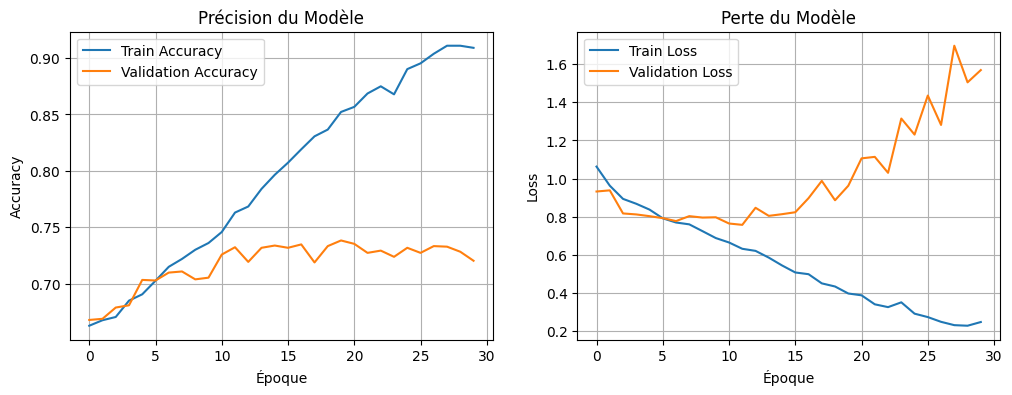

In [ ]:
import matplotlib.pyplot as plt

# Tracé de la précision
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Précision du Modèle')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Tracé de la perte (loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Perte du Modèle')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcul des poids pour chaque classe en fonction de leur rareté
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['dx']),
    y=train_df['dx']
)

# Création du dictionnaire de correspondance
class_weights_dict = dict(enumerate(class_weights))
print("Poids des classes calculés :", class_weights_dict)

Poids des classes calculés : {0: np.float64(4.325621746674378), 1: np.float64(2.7607973421926912), 2: np.float64(1.3125658125658126), 3: np.float64(12.569747899159664), 4: np.float64(1.2934970598408855), 5: np.float64(0.21325919589392645), 6: np.float64(9.712987012987012)}


In [ ]:
# Définition d'un nombre d'époques plus élevé pour laisser le temps au modèle d'apprendre
EPOCHS = 15

# Lancement de l'entraînement avec prise en compte du déséquilibre
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights_dict
)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Générer les prédictions sur le jeu de validation
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Afficher le rapport de classification détaillé par classe
print("Rapport de classification :")
print(classification_report(y_true, y_pred))

# 3. Tracer la matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.show()

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Pour éviter le surapprentissage (overfitting)

# Couche de sortie avec 7 neurones (un par classe) et une activation softmax
predictions = Dense(7, activation='softmax')(x)

# 4. Assembler le nouveau modèle final
model_transfer = Model(inputs=base_model.input, outputs=predictions)

# 5. Compiler le modèle
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Définition du nombre d'époques (par exemple 10 pour commencer)
EPOCHS_TRANSFER = 30

# Lancement de l'entraînement du modèle avec transfer learning
history_transfer = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_TRANSFER,
    class_weight=class_weights_dict
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 290s 5s/step - accuracy: 0.4558 - loss: 1.4027 - val_accuracy: 0.2535 - val_loss: 2.8568
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.6466 - loss: 0.8644 - val_accuracy: 0.1471 - val_loss: 4.3810
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6838 - loss: 0.6594 - val_accuracy: 0.0144 - val_loss: 7.3729
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.6953 - loss: 0.6199 - val_accuracy: 0.0144 - val_loss: 18.3344
Epoch 5/30
11/30 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7512 - loss: 0.3322

KeyboardInterrupt: 

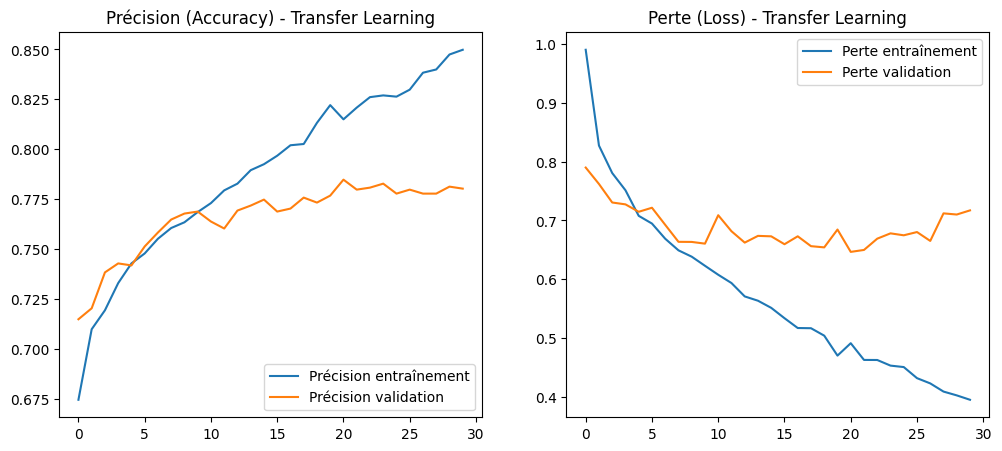

In [ ]:
import matplotlib.pyplot as plt

acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']
loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Graphique de la précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Précision entraînement')
plt.plot(epochs_range, val_acc, label='Précision validation')
plt.legend(loc='lower right')
plt.title('Précision (Accuracy) - Transfer Learning')

# Graphique de la perte (loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perte entraînement')
plt.plot(epochs_range, val_loss, label='Perte validation')
plt.legend(loc='upper right')
plt.title('Perte (Loss) - Transfer Learning')

plt.show()

In [6]:
# 1. On dégèle la base du modèle (que l'on suppose avoir été stockée dans la variable base_model)
base_model.trainable = True

# On choisit de ne dégeler que les 30 dernières couches pour le fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 2. Recompilation du modèle avec un taux d'apprentissage très faible (learning rate)
from tensorflow.keras.optimizers import Adam

model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modèle prêt pour le Fine-Tuning !")

Modèle prêt pour le Fine-Tuning !


In [7]:
EPOCHS_FINETUNE = 40

history_finetune = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINETUNE,
)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.2982 - loss: 1.8997 - val_accuracy: 0.2358 - val_loss: 1.9056
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5453 - loss: 1.4071 - val_accuracy: 0.5203 - val_loss: 1.5181
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6268 - loss: 1.2116 - val_accuracy: 0.6358 - val_loss: 1.2946
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6597 - loss: 1.0998 - val_accuracy: 0.6556 - val_loss: 1.1997
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6705 - loss: 1.0286 - val_accuracy: 0.6631 - val_loss: 1.1407
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6775 - loss: 0.9940 - val_accuracy: 0.6668 - val_loss: 1.1020
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6861 - loss: 0.9585 - val_accuracy: 0.6695 - val_loss: 1.0738
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6981 - loss: 0.9021 - val_accuracy: 0.6701 - val_loss

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=20,      # Légères rotations
    width_shift_range=0.1,  # Décalages horizontaux
    height_shift_range=0.1, # Décalages verticaux
    shear_range=0.1,        # Cisaillement
    zoom_range=0.1,         # Zooms
    horizontal_flip=True,   # Effet miroir horizontal
    vertical_flip=True      # Effet miroir vertical (utile en imagerie médicale)
)

val_datagen = ImageDataGenerator(rescale=1./255.0)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 7479 validated image filenames belonging to 7 classes.
Found 1870 validated image filenames belonging to 7 classes.


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False

from tensorflow.keras.optimizers import Adam

model_transfer.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modèle prêt pour un Fine-Tuning approfondi !")

Modèle prêt pour un Fine-Tuning approfondi !


In [ ]:
EPOCHS_DEEP_FT = 30

history_deep_ft = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEP_FT,
    class_weight=class_weights_dict
)

Epoch 1/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 248s 843ms/step - accuracy: 0.4543 - loss: 1.4824 - val_accuracy: 0.5861 - val_loss: 1.2761
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 172s 734ms/step - accuracy: 0.5835 - loss: 1.0358 - val_accuracy: 0.6171 - val_loss: 1.0583
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 172s 737ms/step - accuracy: 0.6379 - loss: 0.8742 - val_accuracy: 0.5647 - val_loss: 1.2107
Epoch 4/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 172s 734ms/step - accuracy: 0.6783 - loss: 0.7338 - val_accuracy: 0.5759 - val_loss: 1.2406
Epoch 5/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 171s 731ms/step - accuracy: 0.7048 - loss: 0.6361 - val_accuracy: 0.6176 - val_loss: 1.1681
Epoch 6/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 169s 724ms/step - accuracy: 0.7132 - loss: 0.5968 - val_accuracy: 0.7738 - val_loss: 0.6490
Epoch 7/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 171s 728ms/step - accuracy: 0.7413 - loss: 0.5271 - val_accuracy: 0.6647 - val_loss: 1.0573
Epoch 8/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 170s 723ms/step - accuracy: 0.7524 -

KeyboardInterrupt: 

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
--- Rapport de Classification ---
              precision    recall  f1-score   support

       akiec       0.49      0.43      0.46        61
         bcc       0.63      0.50      0.56        98
         bkl       0.52      0.41      0.45       202
          df       0.00      0.00      0.00        22
         mel       0.57      0.29      0.38       209
          nv       0.82      0.96      0.89      1252
        vasc       1.00      0.19      0.32        26

    accuracy                           0.76      1870
   macro avg       0.58      0.40      0.44      1870
weighted avg       0.73      0.76      0.73      1870



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


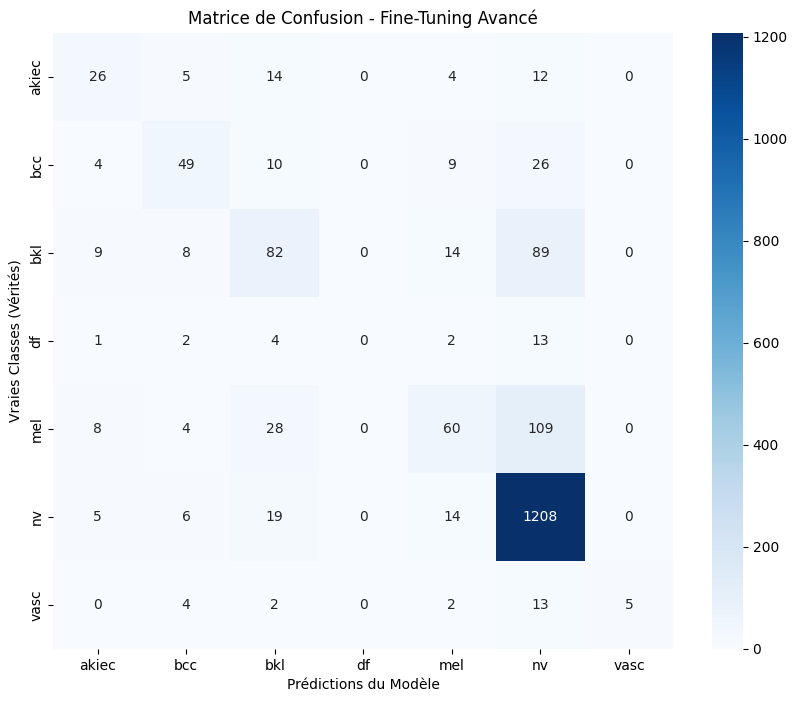

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

val_generator.reset()
Y_pred = model_transfer.predict(val_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)

y_true = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

print("--- Rapport de Classification ---")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Vraies Classes (Vérités)')
plt.title('Matrice de Confusion - Fine-Tuning Avancé')
plt.show()

In [ ]:
tf.keras.models.load_model("/content/medroute_melanoma_model.h5")

<Functional name=functional_3, built=True>

In [9]:
model_transfer.save('medroute_melanoma_model.h5')
print("Modèle sauvegardé avec succès !")

Modèle sauvegardé avec succès !


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_skin_lesion(img_path, model, class_labels):
    """
    Fonction pour prédire la classe d'une lésion cutanée à partir d'une image unique.
    """
    img = image.load_img(img_path, target_size=(224, 224))

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    x = x / 255.0

    predictions = model.predict(x)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    predicted_class_name = class_labels[predicted_class_idx]

    print(f"--- Résultat de l'analyse MedRoute AI ---")
    print(f"Lésion prédite : {predicted_class_name} avec une confiance de {confidence:.2f}%")

    print("\nProbabilités détaillées par classe :")
    for idx, prob in enumerate(predictions[0]):
        print(f"- {class_labels[idx]} : {prob * 100:.2f}%")

    return predicted_class_name, confidence


class_labels = list(val_generator.class_indices.keys())

mon_image_a_tester = '../data/raw/melanoma/HAM10000_images_part_1/ISIC_0027204.jpg'

predict_skin_lesion(mon_image_a_tester, model_transfer, class_labels)

In [ ]:
import pandas as pd

mel_example = val_df[val_df['dx'] == 'mel'].iloc[0]
chemin_melanome = mel_example['path']

print(f"Chemin de l'image de mélanome : {chemin_melanome}")

In [ ]:
import pandas as pd

df_meta = pd.read_csv("../data/raw/melanoma/HAM10000_metadata.csv")
print(sorted(df_meta["dx"].unique()))